Course link: https://www.youtube.com/watch?v=F0GQ0l2NfHA


Additional course link (theoretical): https://www.youtube.com/watch?v=rNEujZmD2Tg&list=PLoROMvodv4rPOWA-omMM6STXaWW4FvJT8&index=2&t=3123s

## Introduction

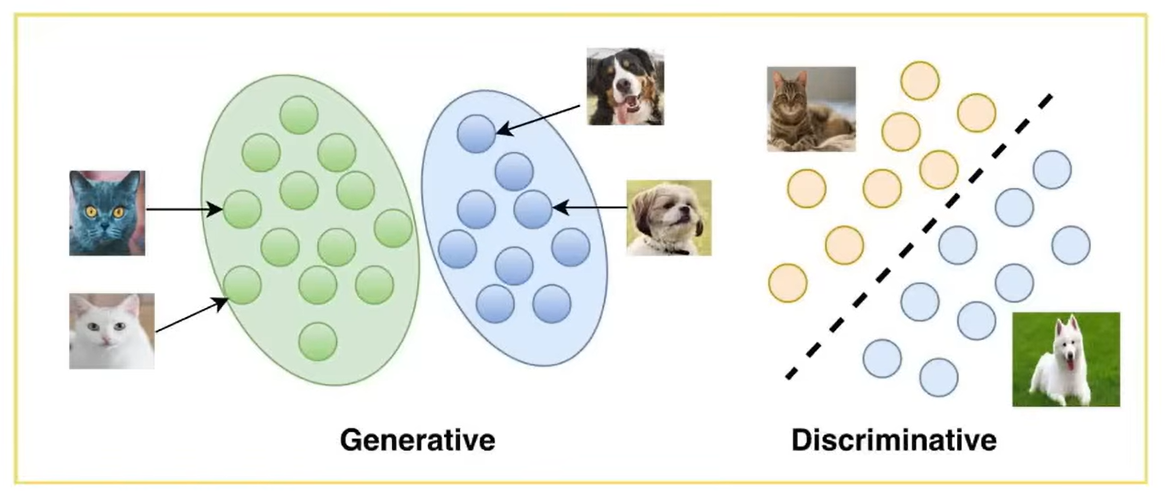
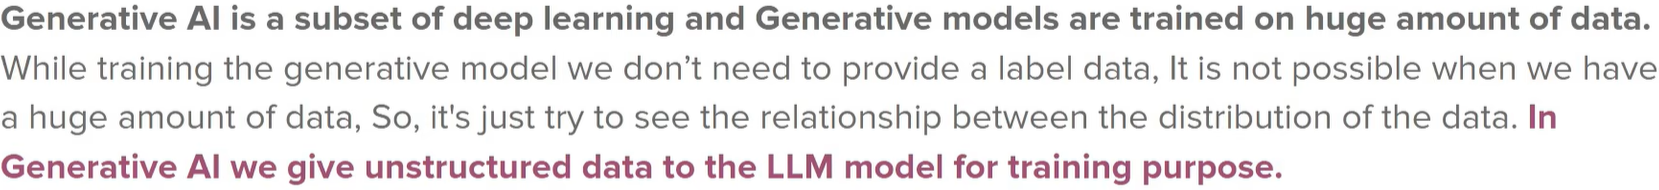

## 1. End to End Generative AI

### Tokenazing
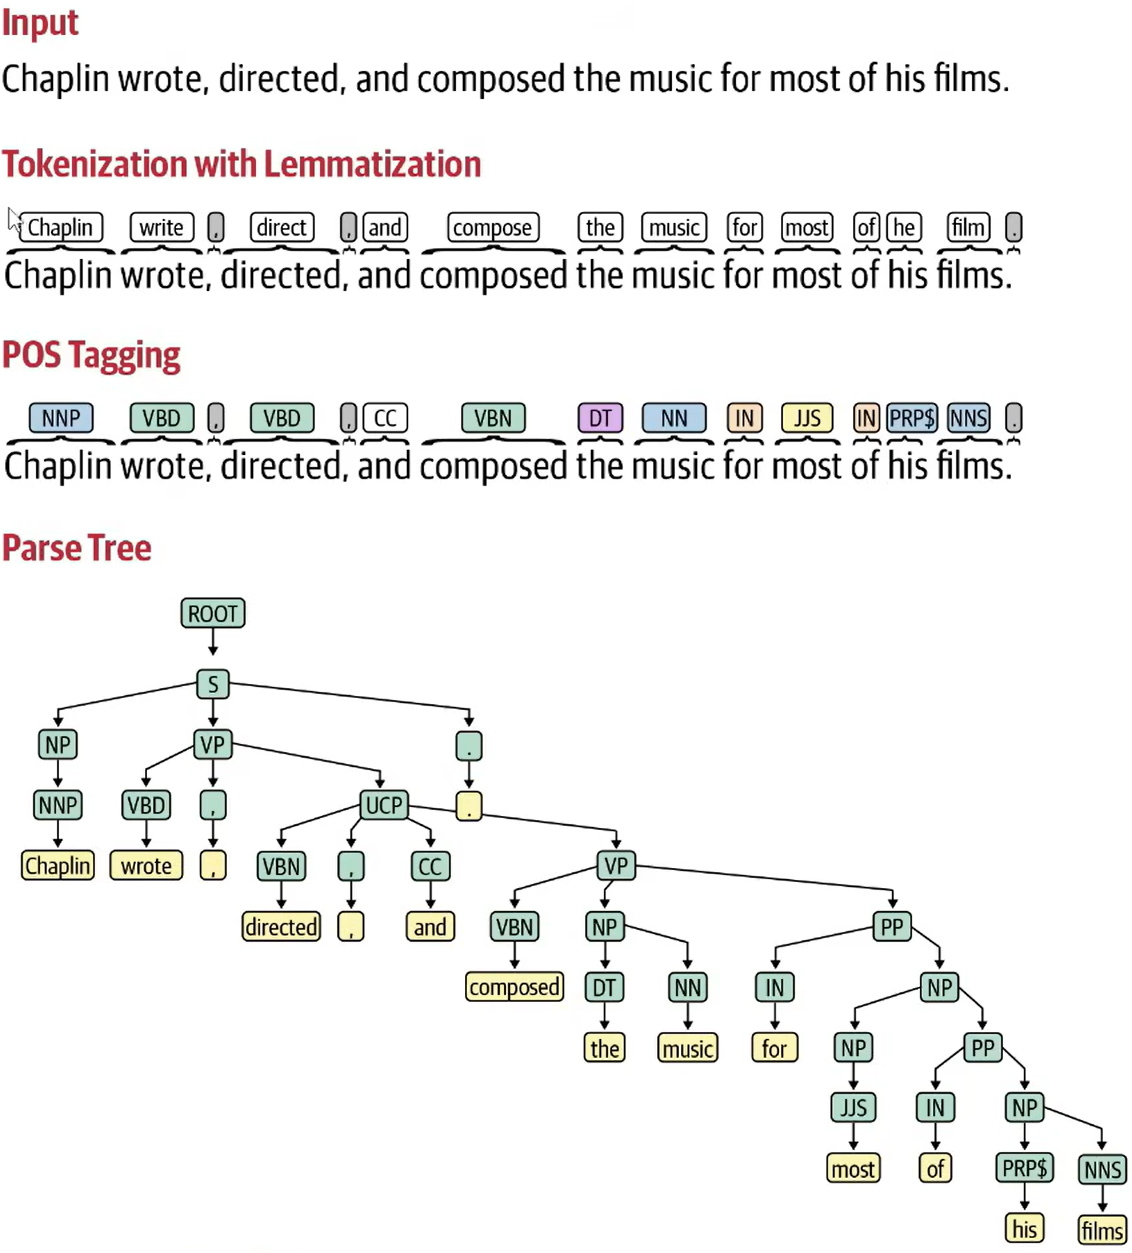

### Text vectorization
* TFIDF
* Bag of Words
* One-Hot
* Word2Vec
* Transformers models

### Modeling
* Open Source LLM
* Paid Model

### Evaluation
* Intrinsive - metrics -> done by GenAI engineer
* Extrinsive - Deployment -> feedback by people usage

## 2. Data Preprocessing & Cleaning

In [1]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
!pip install pyspellchecker
!pip install nltk wordcloud
!pip install emot emoji
!pip install scikit-learn gensim
!pip install seaborn plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 30.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 kB 1.7 MB/s eta 0:00:00


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
from itertools import chain


file_path = "IMDB Dataset.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews", 
    file_path,
)

print("First 5 records:")
print(df.head())

First 5 records:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
df.isnull().sum() # seeing if there are any null entries

review       0
sentiment    0
dtype: int64

In [4]:
df.dropna(inplace=True)

In [5]:
df.duplicated().sum() # seeing if there are any duplicate rows

np.int64(418)

In [6]:
df.drop_duplicates(inplace=True) # removing duplicate rows

In [7]:
df.shape

(49582, 2)

## Clean - Removing HTML tags

In [8]:
import re
# r"<.*?>" → removes all HTML tags
# r"<br\s*/?>" → prevents words from sticking together (replaces line breaks with space)

df["review"] = df["review"].str.replace(r"<br\s*/?>", " ", regex=True).str.replace(r"<.*?>", "", regex=True)  # can use df.apply, slower.

## Clean - Remove urls

In [9]:
df["review"] = df["review"].str.replace(r'https?://\S+|www\.\S+', '', regex=True)

Perfect! Here’s a clean markdown explanation you can put in your Kaggle notebook, matching your code:

---

## Normalize - Lowercase & Numbers

We normalize text in two ways:

### 1. Lowercasing

We use `casefold()` instead of `str.lower()` because it is **more aggressive and consistent for caseless matching**, which is especially helpful for NLP tasks.

**Example:**

```text
"Straße".lower()    -> "straße"
"Straße".casefold() -> "strasse"
```

This ensures that tokens like `"Movie"`, `"movie"`, and `"MOVIE"` are treated identically.

### 2. Number Normalization

We replace all numeric tokens with a generic `<NUM>` token.

**Why normalize numbers?**

* **Reduces vocabulary size:** avoids treating each number as a separate word.
* **Preserves semantic meaning:** most models care about the presence of a number, not the exact value.
* **Consistency:** unifies integers, decimals, or numbers in different formats.
* **Flexibility:** can still capture context like ratings (`<NUM>/10`) or counts.

**Example:**

```text
"I gave it 10/10!"     -> "I gave it <NUM>/<NUM>!"
"3 actors were great"  -> "<NUM> actors were great"
```

In [10]:
import re
def normalize_numbers(text):
    # Replace numbers with a generic token <NUM>
    return re.sub(r'\b\d+(\.\d+)?\b', "<NUM>", text)

df["review"] = df["review"].apply(normalize_numbers)

df["review"] = df["review"].str.casefold() 

## Punctuaion Handling

In [11]:
# exploratory analysis of punctuation
# List of punctuation characters to check
punct_chars = r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""  # string.punctuation

# Count **single punctuation occurrences**
all_puncts = df['review'].str.findall(f"[{re.escape(punct_chars)}]").explode()
punct_freq = all_puncts.value_counts()
print("Single punctuation frequency:\n", punct_freq.head(20))

# Count **punctuation sequences** (2 or more repeated puncts, e.g., !!, ???, ...)
seq_pattern = r'([!?.]{2,})'  # you can extend it if you like
all_sequences = df['review'].str.findall(seq_pattern).explode()
seq_freq = all_sequences.value_counts()
print("\nRepeated punctuation sequences frequency:\n", seq_freq.head(20))

# Optional: check for emoticons (simple common ones)
emoticon_pattern = r'[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]'
all_emoticons = df['review'].str.findall(emoticon_pattern).explode()
emoticon_freq = all_emoticons.value_counts()
print("\nEmoticon frequency:\n", emoticon_freq.head(20))

Single punctuation frequency:
 review
.    643588
,    540760
'    261758
-    131024
"    130771
)     70686
(     69045
>     67596
<     67435
!     48506
?     32052
:     19485
*     13794
;     13285
/     13122
&      7673
`      1828
$      1611
_       974
%       860
Name: count, dtype: int64

Repeated punctuation sequences frequency:
 review
...         19369
..           3248
....         2389
!!           2197
!!!          1721
.....         677
??            590
?!            518
!!!!          481
???           467
!.            276
......        256
!!!!!         225
.......       148
!?            138
????           96
........       79
?!?            75
...?           73
!!!!!!         66
Name: count, dtype: int64

Emoticon frequency:
 review
:)     369
:-)    105
;)      98
:d      60
;-)     55
:(      46
:p      30
=)      22
:-(     14
:o)     14
=d      13
8p      12
:-d     11
;d      11
::      10
:/       7
;o)      6
=]       5
:[       5
=p       5
Name: coun

### Punctuation Exploration and Cleaning

In IMDB reviews, punctuation can carry important sentiment information (e.g., `!`, `?`, `...`) or appear as emoticons (`:)`, `:(`, etc.). However, much of it (commas, periods, quotes, hyphens, etc.) is just grammatical noise.

**What we did:**

1. **Exploration:**

   * Counted **single punctuation** occurrences to see which marks are most frequent.
   * Counted **repeated punctuation sequences** (e.g., `!!`, `???`, `...`) and **emoticons** to check their presence and frequency.
   * This allowed us to make an informed decision rather than blindly removing all punctuation.

2. **Decision for cleaning:**

   * **Keep single punctuation** that carries sentiment: `!` and `?`.
   * **Keep repeated sequences** of punctuation (e.g., `!!`, `???`, `...`) and **normalize them** (e.g., `!!!` → `!!+`).
   * **Keep emoticons** (`:)`, `:(`, `;-P`, etc.) because they directly indicate sentiment.
   * **Remove all other punctuation** that does not contribute to sentiment.

**Simpler alternatives:**

* Remove all punctuation: `df["review"].str.replace(r'[^\w\s]', '', regex=True)`
* Replace all punctuation with spaces: `df["review"].str.replace(r'[^\w\s]', ' ', regex=True)`

**Outcome:**

* Preserves sentiment-bearing punctuation and emoticons while cleaning irrelevant symbols,
* Normalizes repeated sequences to reduce token sparsity (`!!!` → `!!+`, `????` → `??+`),
* Ensures text is ready for tokenization or NLP modeling.

In [12]:
import re

def custom_tokenize(text):
    return re.findall(
        r"\w+|[!?]+|\.\.\.|[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]",
        text
    )

all_tokens_post_chat = list(chain.from_iterable(df["review"].apply(custom_tokenize)))
unique_words_post_chat = set(all_tokens_post_chat)

print(f"Number of unique tokens : {len(unique_words_post_chat)}")

Number of unique tokens : 101150


In [13]:
import re
from emot.emo_unicode import EMOTICONS_EMO
# -----------------------------
# Define what to keep
# -----------------------------
keep_single = "!?"        # single punctuation to preserve
keep_sequences = r"(\.\.\.|!!+|\?\?+|\?!+|!\?+)"  # repeated sequences
emoticon_pattern = r'[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]'

# -----------------------------
# Function: normalize repeated sequences
# -----------------------------
def normalize_punct(seq):
    if re.fullmatch(r'!{2,}', seq):
        return "!!+"      # cap exclamation sequences
    elif re.fullmatch(r'\?{2,}', seq):
        return "??+"      # cap question sequences
    elif re.fullmatch(r'\.{2,}', seq):
        return "..."      # cap ellipses
    elif re.fullmatch(r'(!\?|\?\!){2,}', seq):
        return seq[:2]    # just keep first two mixed
    return seq

# -----------------------------
# Remove all punctuation except sentiment-bearing sequences
# -----------------------------
def clean_review(text):
    # Keep only allowed punctuation/emoticons
    text = re.sub(
        rf"(?!{keep_single}|{keep_sequences}|{emoticon_pattern})[^\w\s]",
        " ",
        text
    )
    # Normalize repeated sequences
    def repl(match):
        return normalize_punct(match.group(0))
    
    text = re.sub(r'(\.\.\.|!!+|\?\?+|!\?+|\?\!+)', repl, text)
    return text


def normalize_emoticons(text: str) -> str:
    """
    Replace ASCII emoticons in text with their sentiment tokens.

    Args:
        text (str): Input string containing text and emoticons.

    Returns:
        str: Text with emoticons replaced by standardized sentiment tokens.
    """
    if not text:
        return text

    # Compile regex pattern from all emoticons
    pattern = re.compile("|".join(map(re.escape, EMOTICONS_EMO.keys())))

    # Replace each emoticon with its mapped value
    return pattern.sub(lambda m: EMOTICONS_EMO[m.group()], text)


# Apply to dataframe
df['review_clean'] = df['review'].apply(clean_review)
df['review_clean'] = df['review_clean'].apply(normalize_emoticons)



In [14]:
import re

def custom_tokenize(text):
    return re.findall(
        r"\w+|[!?]+|\.\.\.|[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]",
        text
    )

all_tokens_post_chat = list(chain.from_iterable(df["review_clean"].apply(custom_tokenize)))
unique_words_post_chat = set(all_tokens_post_chat)

print(f"Number of unique tokens: {len(unique_words_post_chat)}")

Number of unique tokens: 101577


## Chat Conversion Handler

In [15]:
chat_words = {
    "fyi": "for your information",
    "asap": "as soon as possible",
    "brb": "be right back",
    "btw": "by the way",
    "omg": "oh my god",
    "imo": "in my opinion",
    "lol": "laugh out loud",
    "ttyl": "talk to you later",
    "gtg": "got to go",
    "ttyt": "talk to you tomorrow",
    "idk": "i don't know",
    "tmi": "too much information",
    "imho": "in my humble opinion",
    "icymi": "in case you missed it",
    "afaik": "as far as i know",
    "faq": "frequently asked questions",
    "tgif": "thank god it's friday",
    "fya": "for your action",
    "smh": "shaking my head",
    "ftw": "for the win",
    "btwn": "between",
    "np": "no problem",
    "yolo": "you only live once",
    "omfg": "oh my freaking god",
    "rofl": "rolling on the floor laughing",
    "lmao": "laughing my ass off",
    "bff": "best friends forever",
    "jk": "just kidding",
    "idc": "i don't care",
    "tbh": "to be honest",
    "yk": "you know"
}

# Function to replace chat words in text
def replace_chat_words(text, chat_dict):
    # Compile regex pattern from dictionary keys
    pattern = re.compile(r'\b(' + '|'.join(chat_dict.keys()) + r')\b', flags=re.I)
    # Replace each occurrence with the corresponding value
    return pattern.sub(lambda x: chat_dict[x.group().lower()], text)

# Apply the function to the dataframe
df['review_clean'] = df['review_clean'].apply(lambda x: replace_chat_words(x, chat_words))

## Tokenization

### Tokenization Strategy

Tokenization is the process of splitting text into smaller units (tokens), typically words or symbols. This step is critical because it directly affects how the model interprets and learns from the text.

#### Common Tokenization Approaches

1. **Simple Split (`str.split`)**
   - Splits text by whitespace.
   - ✅ Very fast and simple  
   - ❌ Does not handle punctuation (`"movie!!!"` stays as one token)  
   - ❌ No control over token structure  

2. **NLTK Tokenization**
   - Uses predefined linguistic rules.
   - ✅ Better than simple splitting  
   - ❌ Splits punctuation sequences (`"!!!"` → `"!", "!", "!"`)  
   - ❌ Not tailored for sentiment-aware preprocessing  

3. **spaCy Tokenization**
   - Linguistically informed tokenizer.
   - ✅ Handles grammar and structure well  
   - ❌ Heavy and slower  
   - ❌ Still splits expressive punctuation (e.g., `"!!!"`)  

4. **Transformer Tokenizers (e.g., BERT)**
   - Subword tokenization used in modern models.
   - ✅ Required for transformer-based models  
   - ❌ Not suitable for preprocessing/cleaning stage  
   - ❌ Breaks words into subwords (less interpretable)  

---

#### ✅ Chosen Approach: Regex-based Tokenization

We chose a **custom regex tokenizer** to have full control over how text is split.

This allows us to:

- Preserve **words and contractions** (`"don't"`)  
- Preserve **elongated words** (`"soooo"`)  
- Preserve **punctuation sequences** (`"!!!"`, `"???"`, `"..."`)  
- Preserve **emoticons** (`":)"`, `":("`)  

Example:


In [16]:
import re

def custom_tokenize(text):
    return re.findall(
        r"\w+|[!?]+|\.\.\.|[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]",
        text
    )


df["tokens"] = df['review_clean'].apply(custom_tokenize)

df[['review_clean', "tokens"]]

,review_clean,tokens
0,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production. the filming t...,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there's a family where a little boy ...,"[basically, there, s, a, family, where, a, lit..."
4,"petter mattei's ""love in the time of money"" is...","[petter, mattei, s, love, in, the, time, of, m..."
...,...,...
49995,i thought this movie did a down right good job...,"[i, thought, this, movie, did, a, down, right,..."
49996,"bad plot, bad dialogue, bad acting, idiotic di...","[bad, plot, bad, dialogue, bad, acting, idioti..."
49997,i am a catholic taught in parochial elementary...,"[i, am, a, catholic, taught, in, parochial, el..."
49998,i'm going to have to disagree with the previou...,"[i, m, going, to, have, to, disagree, with, th..."


In [17]:
# Flatten all tokens
all_tokens = [token for tokens in df["tokens"] for token in tokens]

# Get unique words
unique_words = set(all_tokens)

# Count
num_unique = len(unique_words)
print(f"Number of unique words: {num_unique}")

Number of unique words: 101557


## Handling Single letter words

In [18]:
# -----------------------------
# Handling Single-Letter Words
# -----------------------------
# This step removes noise single letters but keeps meaningful ones like "i" and "a"
def filter_single_letters(tokens):
    """
    Keep tokens that are either:
      - longer than 1 character
      - or a meaningful single-letter word ('i', 'a')
    """
    return [word for word in tokens if len(word) > 1 or word.lower() in {"i", "a"}]

# -----------------------------
# Apply on tokenized reviews
# -----------------------------
# Assuming 'tokens' column contains the tokenized reviews
df["tokens_filtered"] = df["tokens"].apply(filter_single_letters)

# Quick check
print("Example before filtering:", df["tokens"].iloc[0][:15])
print("Example after filtering: ", df["tokens_filtered"].iloc[0][:15])

Example before filtering: ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'num', 'oz', 'episode', 'you']
Example after filtering:  ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'num', 'oz', 'episode', 'you']


In [19]:
# Flatten all tokens
all_tokens = [token for tokens in df["tokens_filtered"] for token in tokens]

# Get unique words
unique_words = set(all_tokens)

# Count
num_unique = len(unique_words)
print(f"Number of unique words: {num_unique}")

Number of unique words: 101518


## Mispelled Text Handling

### Handling Misspellings in Reviews

In this step, we applied a **smart typo correction** to our IMDB reviews dataset. The goal was to **correct genuine spelling mistakes** (e.g., “movi” → “movie”, “amazng” → “amazing”) while **preserving intentional elongations** and stylistic spellings (e.g., “soooo”, “loooove”) that often convey **emotional intensity or sentiment**.

Since the text was already tokenized, we operated **directly on tokens** instead of splitting raw text again.

We accomplished this by:

1. Iterating over each token in the tokenized reviews.
2. Skipping non-word tokens (e.g., punctuation, emoticons like `!!!`, `:)`).
3. Detecting words with **three or more repeated letters** — these were assumed to be intentional emphasis and left unchanged.
4. Applying a **dictionary-based spellchecker** (now using `SymSpell`) to the remaining tokens to fix actual typos.

#### ⚡ Efficiency Considerations

Spellchecking is a **computationally expensive operation**, especially for large datasets. To optimize performance, we:

* Extracted **unique tokens** from the dataset.
* Computed corrections **once per unique token** using a **single-threaded, cached approach**.
* Stored the results in a **lookup dictionary**.
* Reused these corrections when applying to all reviews.
* Added **timing checkpoints** to monitor how long each sub-step takes, helping identify bottlenecks for further optimization.

> Optional: Multiprocessing could be used to parallelize corrections across cores, but with large dictionaries it may not always improve performance due to memory overhead per worker.

This approach **dramatically reduces redundant computations** and improves scalability, especially for datasets with many repeated words.

#### Why not blindly correct everything?

* Many reviews contain **expressive elongations** or stylized words that carry **sentiment information**. Blindly normalizing them could remove these subtle cues, which might **hurt sentiment analysis performance**.

  

**Note**: Some typos may be rare tokens that even SymSpell cannot confidently correct, so we accept a small fraction of uncorrected words.

#### Potential considerations for the future

* One possible improvement is to **normalize elongated words into a “base + intensity” format** (e.g., `soooo` → `soo+`) to **retain emotional strength** while simplifying tokenization.
* This could help reduce vocabulary size without losing sentiment cues, but it’s optional and depends on the modeling approach.

Overall, this approach provides a **balance between correcting real mistakes, keeping stylistic richness, and being computationally efficient**, enabling it to **scale to larger datasets**.

In [20]:
# -----------------------------
# Optimized Smart Typo Correction with SymSpell
# -----------------------------
!pip install symspellpy --quiet

import re
from symspellpy.symspellpy import SymSpell, Verbosity
from itertools import chain
import time
import pkg_resources

# Initialize SymSpell
max_edit_distance = 2
prefix_length = 7
sym_spell = SymSpell(max_edit_distance, prefix_length)

# Load dictionary: use the provided frequency dictionary included in symspellpy package
dictionary_path = pkg_resources.resource_filename(
    "symspellpy", "frequency_dictionary_en_82_765.txt"
)
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
# -----------------------------
# Helper: check if a word is elongated (3+ repeated letters)
# -----------------------------
def is_elongated(word):
    for i in range(len(word)-2):
        if word[i] == word[i+1] == word[i+2]:
            return True
    return False

# -----------------------------
# 1. Flatten all tokens efficiently
# -----------------------------
start = time.time()
all_words = list(chain.from_iterable(df["tokens_filtered"]))
print(f"Flattening tokens: {time.time() - start:.2f}s")

# -----------------------------
# 2. Get unique words
# -----------------------------
start = time.time()
unique_words = set(all_words)
print(f"Unique word extraction: {time.time() - start:.2f}s")

# -----------------------------
# 3. Precompute corrections (cache)
# -----------------------------
def correct_word(word):
    # Skip non-alpha tokens (punctuation, emoticons)
    if not word.isalpha():
        return word
    # Skip elongated words
    elif is_elongated(word):
        return word
    else:
        suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance)
        if suggestions:
            return suggestions[0].term
        else:
            return word

start = time.time()
correction_map = {word: correct_word(word) for word in unique_words}
print(f"SymSpell checking unique words: {time.time() - start:.2f}s")

# -----------------------------
# 4. Apply cached corrections to tokenized data
# -----------------------------
def fast_typo_fix(tokens):
    return [correction_map[word] for word in tokens]

start = time.time()
df["tokens_fixed"] = df["tokens_filtered"].apply(fast_typo_fix)
print(f"Applying corrections to all rows: {time.time() - start:.2f}s")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 24.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 6.5 MB/s eta 0:00:00


/tmp/ipykernel_55/3783624527.py:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Flattening tokens: 0.46s
Unique word extraction: 0.70s
SymSpell checking unique words: 5.05s
Applying corrections to all rows: 6.34s


In [21]:
df.head()

,review,sentiment,review_clean,tokens,tokens_filtered,tokens_fixed
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, of, the, other, reviewers, has, mentione...","[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production. the filming t...,positive,a wonderful little production. the filming t...,"[a, wonderful, little, production, the, filmin...","[a, wonderful, little, production, the, filmin...","[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[i, thought, this, was, a, wonderful, way, to,...","[i, thought, this, was, a, wonderful, way, to,..."
3,basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...,"[basically, there, s, a, family, where, a, lit...","[basically, there, a, family, where, a, little...","[basically, there, a, family, where, a, little..."
4,"petter mattei's ""love in the time of money"" is...",positive,"petter mattei's ""love in the time of money"" is...","[petter, mattei, s, love, in, the, time, of, m...","[petter, mattei, love, in, the, time, of, mone...","[petter, matter, love, in, the, time, of, mone..."


In [22]:
# Flatten all tokens
all_tokens = [token for tokens in df["tokens_fixed"] for token in tokens]

# Get unique words
unique_words = set(all_tokens)

# Count
num_unique = len(unique_words)
print(f"Number of unique words: {num_unique}")

Number of unique words: 65678


## Stopwords

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 20 BEFORE stopword removal:
[('the', 663329), ('a', 323580), ('and', 322595), ('of', 293482), ('to', 272930), ('is', 211682), ('in', 193363), ('it', 189993), ('i', 176151), ('this', 149819), ('that', 143510), ('was', 99574), ('as', 91279), ('movie', 87313), ('for', 86948), ('with', 86799), ('but', 82935), ('film', 79215), ('you', 68672), ('on', 67920)]

Top 20 AFTER stopword removal:
[('movie', 87313), ('film', 79215), ('cum', 67042), ('not', 60333), ('one', 53246), ('like', 39874), ('good', 29542), ('would', 26511), ('no', 25261), ('time', 24965), ('even', 24694), ('...', 24667), ('story', 22972), ('really', 22930), ('see', 22849), ('well', 21131), ('much', 19186), ('could', 18441), ('get', 18399), ('bad', 18275)]


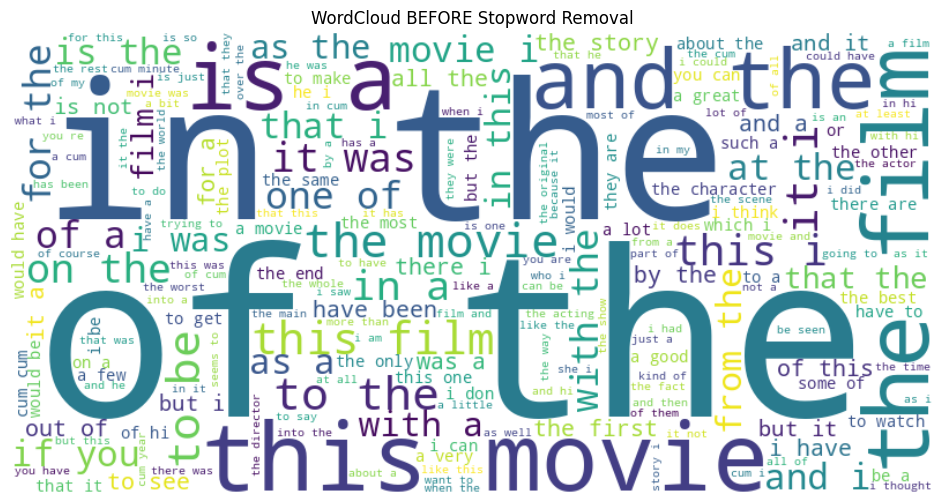

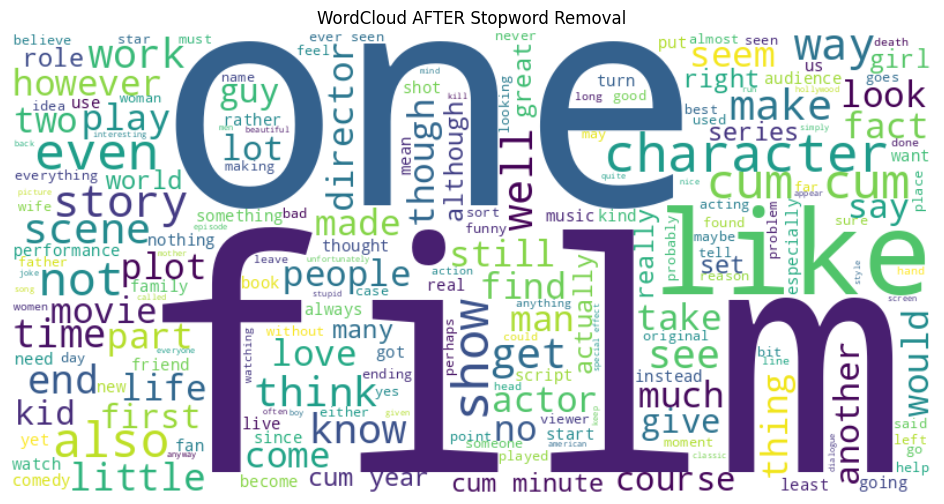

In [23]:
# -----------------------------
# Imports
# -----------------------------
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Download stopwords
nltk.download('stopwords')

# -----------------------------
# Load stopwords
# -----------------------------
stop_words = set(stopwords.words('english'))

# OPTIONAL: keep some sentiment-important words
keep_words = {"not", "no", "nor"}  # important for sentiment
stop_words = stop_words - keep_words

# -----------------------------
# Function: remove stopwords only
# -----------------------------
def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]

# -----------------------------
# Apply stopword removal
# -----------------------------
df["tokens_nostop"] = df["tokens_fixed"].apply(remove_stopwords)

# -----------------------------
# Flatten tokens for analysis
# -----------------------------
all_tokens_before = [token.lower() for tokens in df["tokens_fixed"] for token in tokens]
all_tokens_after  = [token.lower() for tokens in df["tokens_nostop"] for token in tokens]

# -----------------------------
# Frequency count
# -----------------------------
freq_before = Counter(all_tokens_before)
freq_after  = Counter(all_tokens_after)

print("Top 20 BEFORE stopword removal:")
print(freq_before.most_common(20))

print("\nTop 20 AFTER stopword removal:")
print(freq_after.most_common(20))

# -----------------------------
# WordCloud BEFORE
# -----------------------------
wc_before = WordCloud(
    width=800,
    height=400,
    background_color="white",  # white background
    stopwords=set()            # don't remove any words automatically
).generate(" ".join(all_tokens_before))

plt.figure(figsize=(12,6))
plt.imshow(wc_before, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud BEFORE Stopword Removal")
plt.show()

# -----------------------------
# WordCloud AFTER
# -----------------------------
wc_after = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=set()
).generate(" ".join(all_tokens_after))

plt.figure(figsize=(12,6))
plt.imshow(wc_after, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud AFTER Stopword Removal")
plt.show()

## Rare Words Frequncy Count

In [24]:
# Flatten all tokens
all_tokens = [token for tokens in df["tokens_nostop"] for token in tokens]

# Get unique words
unique_words = set(all_tokens)

# Count
num_unique = len(unique_words)
print(f"Number of unique words: {num_unique}")

Number of unique words: 65543


In [25]:
from collections import Counter

all_tokens = [token.lower() for tokens in df["tokens_nostop"] for token in tokens]

freq = Counter(all_tokens)

# Show 20 least common
least_common_40 = freq.most_common()[:-41:-1]
print("40 least common words:")
print(least_common_40)

40 least common words:
[('clatter', 1), ('effortful', 1), ('burtolucci', 1), ('censorial', 1), ('citations', 1), ('pintos', 1), ('demonoïd', 1), ('amplifier', 1), ('yeeeecchh', 1), ('eucharist', 1), ('skype', 1), ('ballplaying', 1), ('yaaayyyy', 1), ('semesters', 1), ('lambent', 1), ('provisos', 1), ('peliculam', 1), ('interning', 1), ('audiocassette', 1), ('pppenheimer', 1), ('pachyderms', 1), ('unzipped', 1), ('creasing', 1), ('abountongue', 1), ('seneca', 1), ('wist', 1), ('forebodings', 1), ('exalting', 1), ('misconstrue', 1), ('balky', 1), ('mstfrown', 1), ('stagnate', 1), ('07b', 1), ('sakhalin', 1), ('carpathians', 1), ('kubrickysh', 1), ('orig', 1), ('ff2', 1), ('helpfulness', 1), ('missolonghi', 1)]


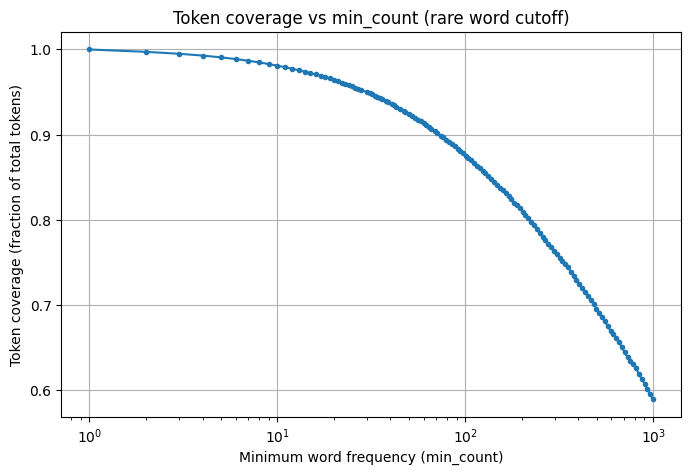

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# freq = your Counter of token frequencies
total_tokens = sum(freq.values())

# Choose thresholds logarithmically from 1 to 1000 (for example)
min_counts = np.unique(np.logspace(0, 3, 200).astype(int))  # 1 to 1000

coverage_list = []

for min_count in min_counts:
    coverage = sum(v for k, v in freq.items() if v >= min_count) / total_tokens
    coverage_list.append(coverage)

# Plot - looking for elbowpoint for treshold to remove rare words
plt.figure(figsize=(8,5))
plt.plot(min_counts, coverage_list, marker='o', markersize=3)
plt.xscale('log')
plt.xlabel("Minimum word frequency (min_count)")
plt.ylabel("Token coverage (fraction of total tokens)")
plt.title("Token coverage vs min_count (rare word cutoff)")
plt.grid(True)
plt.show()

In [27]:
from collections import Counter

all_tokens = [token for tokens in df["tokens_nostop"] for token in tokens]
freq = Counter(all_tokens)

# Threshold: freq <= 7 → rare
rare_tokens = {word for word, count in freq.items() if count <= 7}

def replace_rare(tokens):
    return [t if t not in rare_tokens else "<UNK>" for t in tokens]

df["tokens_final"] = df["tokens_nostop"].apply(replace_rare)

In [28]:
# Flatten all tokens
all_tokens = [token for tokens in df["tokens_final"] for token in tokens]

# Get unique words
unique_words = set(all_tokens)

# Count
num_unique = len(unique_words)
print(f"Number of unique words: {num_unique}")

Number of unique words: 28630


# Feature Extraction from Text/Image

Take out the core features of the data.

---

## Why We Need It?

Convert data to numbers/vectors so that machine learning models can process it.

Raw text or images are not directly understandable by models — they must be transformed into structured representations such as:

* Vectors (e.g., embeddings)
* Frequency-based representations (e.g., Bag of Words, TF-IDF)
* Learned features (e.g., deep neural network embeddings)

This step bridges the gap between **human-readable data** and **machine-readable input**.

---

## Why is It So Difficult?

Feature extraction is challenging because:

* **High dimensionality**:
  Text data can have tens of thousands of unique words (as you saw ~100k → ~18k), making representations sparse and computationally expensive.

* **Context and ambiguity**:
  Words can have different meanings depending on context (e.g., *“bad”* vs *“not bad”*).

* **Loss of information**:
  Simplifying text into vectors can remove important nuances like tone, sarcasm, or emphasis (e.g., *“soooo good!!!”*).

* **Noise in real-world data**:
  Typos, slang, emojis, punctuation, and formatting variations make consistent representation harder.

* **Trade-off between simplicity and meaning**:
  Simple methods (like Bag of Words) are fast but lose structure, while advanced methods (like embeddings) are more powerful but complex.

---

## What is The Core Idea?

The core idea is to represent data in a way that:

* **Captures meaningful patterns** (e.g., sentiment, topics)
* **Reduces noise and redundancy** (e.g., removing stopwords, rare words)
* **Maintains important signals** (e.g., negations like *“not”*, punctuation like *“!”*)

For text specifically, this often involves:

1. **Preprocessing**
   Cleaning and normalizing the text (lowercasing, removing noise, handling typos, etc.)

2. **Tokenization**
   Splitting text into meaningful units (words, subwords, or symbols)

3. **Vocabulary construction**
   Keeping only useful tokens (e.g., removing rare words using thresholds like `min_count`)

4. **Vectorization**
   Converting tokens into numerical representations:

   * Count-based (One-Hot, Bag of Words, TF-IDF)
   * Embedding-based (Word2Vec, GloVe, BERT)

In essence, feature extraction is about **compressing raw data into a structured numerical form that preserves meaning while remaining efficient for learning algorithms**.

---

## Techniques Explanations

### One-Hot Encoding

Each word is represented as a vector of length **V (vocabulary size)** with a single `1` at the word’s index and `0`s elsewhere.

Example (V = 5):
`"movie"` → `[0, 0, 1, 0, 0]`

**Pros:**

* Simple and intuitive
* No training required

**Cons:**

* Very **sparse vectors**
* **High dimensionality** (depends on vocab size)
* **No semantic meaning** (all words equally distant)

---

### Bag of Words (BoW)

Represents a document by counting how many times each word appears. Word order is ignored.

Example:
`"good movie good"` → `[good:2, movie:1]`

**Pros:**

* Simple and effective baseline
* Captures word importance via frequency

**Cons:**

* Ignores **word order and context**
* Still high-dimensional and sparse
* Treats all words independently

---

### TF-IDF (Term Frequency – Inverse Document Frequency)

Improves BoW by weighting words based on importance:

* **TF**: how often a word appears in a document
* **IDF**: how rare the word is across all documents

Rare but important words get higher weights, common words get lower weights.

**Pros:**

* Reduces impact of common words
* Highlights informative terms
* Works well for many classical ML models

**Cons:**

* Still ignores context and word order
* Sparse representation
* No semantic understanding

---

### Word2Vec

Learns **dense vector representations (embeddings)** where similar words have similar vectors.

Based on predicting:

* a word from its context (CBOW)
* or context from a word (Skip-gram)

Example:
`vector("king") - vector("man") + vector("woman") ≈ vector("queen")`

**Pros:**

* Captures **semantic relationships**
* Dense (low-dimensional) vectors
* Much better than count-based methods

**Cons:**

* Context-independent (same vector for every usage of a word)
* Requires training on large corpora

---

### GloVe (Global Vectors)

Similar to Word2Vec but uses **global co-occurrence statistics** instead of local context windows.

**Pros:**

* Captures global statistical information
* Produces high-quality embeddings

**Cons:**

* Still **context-independent**
* Requires pretraining

---

### BERT (Contextual Embeddings)

A transformer-based model that generates **context-aware embeddings**.

The same word gets different vectors depending on context:

* "bank" (river) vs "bank" (money)

**Pros:**

* Captures **context, syntax, and semantics**
* State-of-the-art performance
* Handles polysemy (multiple meanings)

**Cons:**

* Computationally expensive
* Large models
* Requires more resources and tuning

---

## Summary

| Method   | Type      | Captures Meaning? | Context-Aware? | Complexity |
| -------- | --------- | ----------------- | -------------- | ---------- |
| One-Hot  | Count     | ❌                 | ❌              | Low        |
| BoW      | Count     | ❌                 | ❌              | Low        |
| TF-IDF   | Count     | Partial           | ❌              | Low        |
| Word2Vec | Embedding | ✅                 | ❌              | Medium     |
| GloVe    | Embedding | ✅                 | ❌              | Medium     |
| BERT     | Embedding | ✅                 | ✅              | High       |

---

This progression shows the evolution from **simple frequency-based methods → semantic embeddings → fully contextual understanding**, with increasing performance and computational cost.


In [29]:
# -----------------------------
# Convert tokens to text
# -----------------------------
df["text_final"] = df["tokens_final"].apply(lambda tokens: " ".join(tokens))

print(df[["tokens_final", "text_final"]].head())

                                        tokens_final  \
0  [one, reviewers, mentioned, watching, cum, epi...   
1  [wonderful, little, production, filming, techn...   
2  [thought, wonderful, way, spend, time, hot, su...   
3  [basically, family, little, boy, jake, thinks,...   
4  [petter, matter, love, time, money, visually, ...   

                                          text_final  
0  one reviewers mentioned watching cum episode h...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically family little boy jake thinks zombie...  
4  petter matter love time money visually stunnin...  


## Bag of Words (BoW) + Exploration

Shape: (49582, 28610)
Top 20 words (BoW):
[('movie', np.int64(87313)), ('film', np.int64(79215)), ('cum', np.int64(67042)), ('not', np.int64(60333)), ('one', np.int64(53246)), ('like', np.int64(39874)), ('good', np.int64(29542)), ('would', np.int64(26511)), ('no', np.int64(25261)), ('time', np.int64(24965)), ('even', np.int64(24694)), ('story', np.int64(22972)), ('really', np.int64(22930)), ('see', np.int64(22849)), ('well', np.int64(21131)), ('much', np.int64(19186)), ('could', np.int64(18441)), ('get', np.int64(18399)), ('bad', np.int64(18275)), ('people', np.int64(18029))]


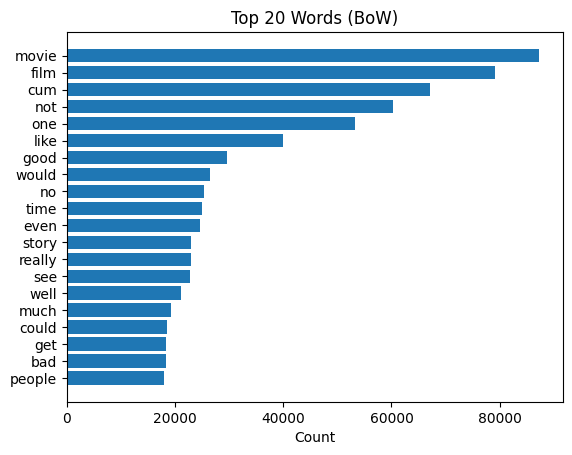

In [30]:
# -----------------------------
# Bag of Words
# -----------------------------
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import matplotlib.pyplot as plt

bow = CountVectorizer(stop_words=["unk"])
X_bow = bow.fit_transform(df["text_final"])

print(f"Shape: {X_bow.shape}")

# -----------------------------
# Top words (global frequency)
# -----------------------------
word_counts = np.asarray(X_bow.sum(axis=0)).flatten()
words = bow.get_feature_names_out()

top_indices = word_counts.argsort()[::-1][:20]

print("Top 20 words (BoW):")
print([(words[i], word_counts[i]) for i in top_indices])

# -----------------------------
# Plot top words
# -----------------------------
top_words = [words[i] for i in top_indices]
top_counts = [word_counts[i] for i in top_indices]

plt.figure()
plt.barh(top_words[::-1], top_counts[::-1])
plt.title("Top 20 Words (BoW)")
plt.xlabel("Count")
plt.show()

## TF-IDF + Exploration

Shape: (49582, 28610)
Top 20 TF-IDF words:
[('movie', np.float64(0.04824467895034357)), ('film', np.float64(0.03978234136953279)), ('cum', np.float64(0.03537751375428562)), ('not', np.float64(0.029346406555179467)), ('one', np.float64(0.02648295890457387)), ('like', np.float64(0.02265665270371262)), ('good', np.float64(0.020247742177163075)), ('would', np.float64(0.01765923178796013)), ('really', np.float64(0.01718019595626029)), ('no', np.float64(0.016705473369694954)), ('story', np.float64(0.016704403747402168)), ('time', np.float64(0.016673445290596587)), ('see', np.float64(0.016587105114460363)), ('even', np.float64(0.016320695884059072)), ('bad', np.float64(0.016116545678760863)), ('great', np.float64(0.015157468325679397)), ('well', np.float64(0.014812385106114458)), ('movies', np.float64(0.014057991790618651)), ('could', np.float64(0.014046823455589875)), ('people', np.float64(0.013897310806850778))]


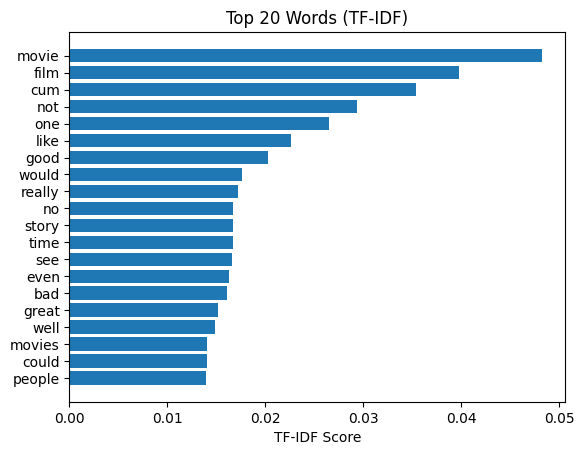

In [31]:
# -----------------------------
# TF-IDF
# -----------------------------
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words=["unk"])
X_tfidf = tfidf.fit_transform(df["text_final"])

print(f"Shape: {X_tfidf.shape}")

# -----------------------------
# Top global TF-IDF words
# -----------------------------
tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).flatten()
feature_names = tfidf.get_feature_names_out()

top_indices = tfidf_scores.argsort()[::-1][:20]

print("Top 20 TF-IDF words:")
print([(feature_names[i], tfidf_scores[i]) for i in top_indices])

# -----------------------------
# Plot
# -----------------------------
top_words = [feature_names[i] for i in top_indices]
top_scores = [tfidf_scores[i] for i in top_indices]

plt.figure()
plt.barh(top_words[::-1], top_scores[::-1])
plt.title("Top 20 Words (TF-IDF)")
plt.xlabel("TF-IDF Score")
plt.show()

## Document Similarity (BoW vs TF-IDF)

In [32]:
# -----------------------------
# Similarity comparison
# -----------------------------
from sklearn.metrics.pairwise import cosine_similarity

doc1, doc2 = 0, 1

sim_bow = cosine_similarity(X_bow[doc1], X_bow[doc2])[0][0]
sim_tfidf = cosine_similarity(X_tfidf[doc1], X_tfidf[doc2])[0][0]

print(f"BoW similarity: {sim_bow:.4f}")
print(f"TF-IDF similarity: {sim_tfidf:.4f}")

BoW similarity: 0.1038
TF-IDF similarity: 0.0241


## Word2Vec (Semantic Exploration)

In [33]:
# -----------------------------
# Train Word2Vec
# -----------------------------
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=df["tokens_final"],
    vector_size=140,
    window=5,
    min_count=1,
    workers=4
)

# -----------------------------
# Similar words
# -----------------------------
print("Similar to 'good':")
print(w2v_model.wv.most_similar("good"))

print("\nSimilar to 'bad':")
print(w2v_model.wv.most_similar("bad"))

Similar to 'good':
[('decent', 0.751356303691864), ('great', 0.6547403931617737), ('alright', 0.6337249279022217), ('bad', 0.623364269733429), ('nice', 0.5956049561500549), ('fine', 0.5898008942604065), ('okay', 0.5846132636070251), ('excellent', 0.5418155789375305), ('acceptable', 0.5415729880332947), ('awesome', 0.5363883972167969)]

Similar to 'bad':
[('awful', 0.7090554237365723), ('terrible', 0.6978324055671692), ('horrible', 0.6918483972549438), ('sucks', 0.638901948928833), ('good', 0.6233643293380737), ('lousy', 0.6224388480186462), ('crappy', 0.6123620271682739), ('lame', 0.5814834237098694), ('atrocious', 0.5802938342094421), ('suck', 0.5797064900398254)]


## Word2Vec Visualization (PCA)

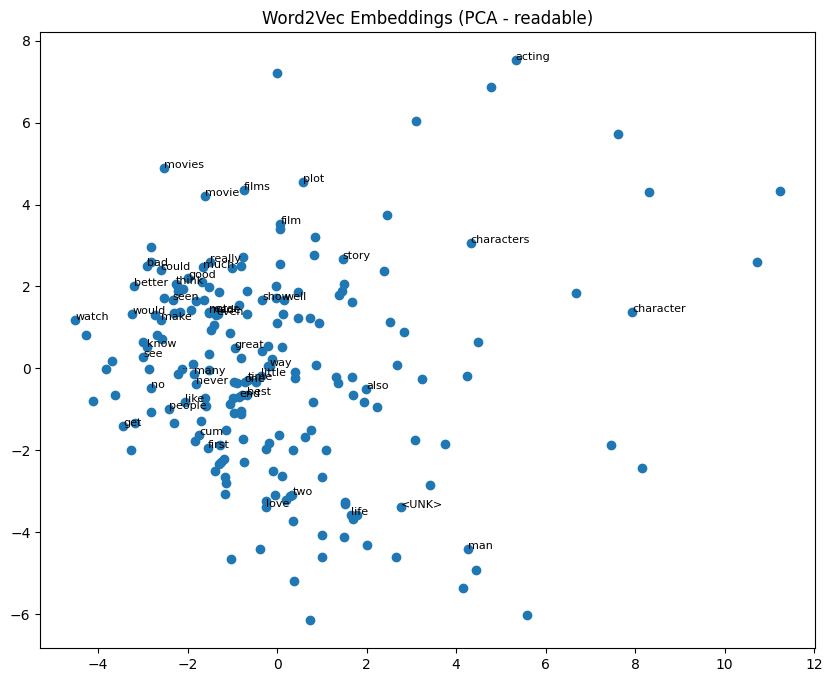

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(w2v_model.wv.index_to_key[:200])
vectors = [w2v_model.wv[w] for w in words]

X_reduced = PCA(n_components=2).fit_transform(vectors)

plt.figure(figsize=(10,8))
plt.scatter(X_reduced[:,0], X_reduced[:,1])

for i, word in enumerate(words[:50]):  # only label 50
    plt.annotate(word, (X_reduced[i,0], X_reduced[i,1]), fontsize=8)

plt.title("Word2Vec Embeddings (PCA - readable)")
plt.show()

## Document Embeddings (Word2Vec avg)

In [35]:
# -----------------------------
# Document embeddings
# -----------------------------
import numpy as np

def doc_embedding(tokens):
    vectors = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v = np.vstack(df["tokens_final"].apply(doc_embedding))

print(f"Shape: {X_w2v.shape}")

Shape: (49582, 140)


## Key Comparison Summary (PRINT)

In [36]:
print("SUMMARY:")
print(f"BoW shape: {X_bow.shape}")
print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"Word2Vec doc shape: {X_w2v.shape}")

print("\nInsights:")
print("- BoW: simple, frequency-based")
print("- TF-IDF: highlights important words")
print("- Word2Vec: captures semantic similarity")

SUMMARY:
BoW shape: (49582, 28610)
TF-IDF shape: (49582, 28610)
Word2Vec doc shape: (49582, 140)

Insights:
- BoW: simple, frequency-based
- TF-IDF: highlights important words
- Word2Vec: captures semantic similarity


# 📝 Text Preprocessing & Feature Extraction Summary

## Feature Extraction Techniques

Text was converted into numerical representations using multiple approaches:

### a. Count-based Methods

1. **Bag of Words (BoW)**

   * Document represented by counts of words
   * Sparse, ignores context

2. **TF-IDF**

   * Weights words by rarity across corpus
   * Highlights informative terms

### b. Embedding-based Methods

1. **Word2Vec**

   * Dense embeddings of words
   * Captures semantic similarity
   * Explored vector sizes: 50, 100, 128, 140, 150

---

## Feature Comparison

### Vocabulary Threshold Experiments

* Tested `min_count = 2, 7, 20`
* Chose **7** as it balanced vocabulary size vs. coverage

### Similarity Metrics

| Method | Similarity (good vs. bad neighbors) |
| ------ | ----------------------------------- |
| BoW    | ~0.10                               |
| TF-IDF | ~0.02                               |

* Lower similarity indicates **sparser, less noisy representation**
* Word2Vec embeddings capture **meaningful semantic clusters**

---

## Word2Vec Exploration

**Vector sizes vs. nearest neighbors (semantic quality)**

* **V = 50**

  * Closer vectors, higher similarity, more compressed → “blurry clusters”
* **V = 100–150**

  * Lower similarity, more nuanced relationships → better semantic structure
* **Observations**

  * “good” ↔ great, decent, nice, fine, okay
  * “bad” ↔ terrible, awful, horrible, lousy, sucks
  * Semantic relationships stable across vector sizes

**Insight:**

> Preprocessing and vocabulary threshold had a larger impact than vector dimensionality on semantic quality.

---

## Lessons Learned

1. **Thresholding rare words matters**

   * Too aggressive → lose important words
   * Too lax → high-dimensional sparse features

2. **Vector size tuning**

   * Smaller vectors: compressed, higher similarity
   * Larger vectors: nuanced, meaningful clusters

3. **`<UNK>` token**

   * Frequent in processed data
   * Can be removed for TF-IDF / BoW
   * Not critical for Word2Vec

4. **Semantic consistency**

   * Nearest neighbors for positive / negative words remain stable
   * Confirms preprocessing pipeline is solid

---

## 7. Summary Table

| Method   | Vector Dim | Captures Meaning | Context-Aware |
| -------- | ---------- | ---------------- | ------------- |
| BoW      | sparse     | ❌                | ❌             |
| TF-IDF   | sparse     | Partial          | ❌             |
| Word2Vec  | 50–150     | ✅                | ❌             |